<a href="https://colab.research.google.com/github/christiangarza1505813/Tesina/blob/main/Model/model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
!pip -q install pandas pyarrow scikit-learn joblib
!pip install pydeck

In [39]:


import matplotlib.pyplot as plt
import seaborn as sns
import io, os, textwrap, joblib, numpy as np, pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, mean_absolute_error, mean_squared_error


In [40]:
CSV_URL = "https://raw.githubusercontent.com/christiangarza1505813/Tesina/main/Datos/user_clasification.csv"  # <-- reemplaza

df = pd.read_csv(
    CSV_URL,
)

In [41]:
CSV_Demo = "https://raw.githubusercontent.com/christiangarza1505813/Tesina/main/Datos/Demo.csv"  # <-- reemplaza

df_demo = pd.read_csv(
    CSV_Demo,
)

In [42]:

df = df.merge(
    df_demo[['Postal_Code', 'Hispanic Percent Population']]  # solo las columnas necesarias
        .rename(columns={'Hispanic Percent Population': 'Hispanic_percent'}),  # renombrar
    how='left',               # left join para no perder registros de df
    left_on='postal_code',    # columna en df
    right_on='Postal_Code'    # columna en df_demo
)

df = df.drop(columns=['Postal_Code'])


In [43]:
df['YMD'] = pd.to_datetime(df['YMD'])
df['YearOfBirth'] = df['YearOfBirth'].astype(int)
df['Creation_date'] = pd.to_datetime(df['Creation_date'])
df_sorted = df.sort_values(by=['AccountUuid', 'YMD'])
df = df_sorted.drop_duplicates(subset=['AccountUuid'], keep='first')
df.describe()

,YMD,Creation_date,Plaid,Issued_Card,Transacting,Pmt_method,YearOfBirth,postal_code,lat,lng,density,Hispanic_percent
count,67678,67678,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67678.000000,67582.000000
mean,2024-06-23 07:05:41.605839104,2024-06-17 02:28:14.305387264,0.042362,0.608839,0.313810,0.132672,1988.604968,64218.323680,35.987574,-98.183960,1668.881913,0.333621
min,2022-08-08 00:00:00,2022-08-08 00:00:00,0.000000,0.000000,0.000000,0.000000,1900.000000,10002.000000,19.306120,-166.471250,0.000000,0.000000
25%,2023-12-25 06:00:00,2023-12-16 00:00:00,0.000000,0.000000,0.000000,0.000000,1983.000000,37241.250000,32.934170,-115.123130,144.700000,0.084000
50%,2024-05-09 00:00:00,2024-05-02 00:00:00,0.000000,1.000000,0.000000,0.000000,1990.000000,75141.000000,35.249220,-95.870100,821.300000,0.253000
75%,2024-12-30 00:00:00,2024-12-23 00:00:00,0.000000,1.000000,1.000000,0.000000,1996.000000,89104.000000,39.723890,-84.549560,1931.500000,0.548000
max,2025-09-13 00:00:00,2025-09-13 00:00:00,1.000000,1.000000,1.000000,1.000000,2007.000000,99901.000000,67.254350,-72.372230,58289.600000,1.000000
std,NaN,NaN,0.201416,0.488014,0.464043,0.339223,10.402508,26328.559487,4.846153,15.499654,3232.997743,0.278518


#Calidad de los datos


##% de nulos

In [44]:

obj_cols = df.select_dtypes(include=['object', 'string']).columns

# Máscaras de vacíos y nulos
mask_empty = pd.DataFrame(False, index=df.index, columns=df.columns)
if len(obj_cols):
    mask_empty[obj_cols] = df[obj_cols].astype('string').apply(lambda s: s.str.strip().eq(''))

mask_null = df.isna()

# Resumen en porcentaje
resumen = pd.DataFrame({
    'Tipo': df.dtypes.astype(str),
    '% nulos o vacíos': ((mask_null | mask_empty).mean()*100).round(2)
}).sort_values('% nulos o vacíos', ascending=False)

sty = (resumen.style
       .format({'% nulos':'{:.2f} %','% vacíos':'{:.2f} %','% nulos o vacíos':'{:.2f} %'})
       .set_table_styles([
           {'selector': 'table', 'props': 'border-collapse:collapse; border:1px solid black; background:white; color:black; font-family:"Times New Roman",serif; font-size:12px;'},
           {'selector': 'th',    'props': 'border:1px solid black; padding:4px; text-align:center; font-weight:bold;'},
           {'selector': 'td',    'props': 'border:1px solid black; padding:4px; text-align:right;'},
           {'selector': 'th.row_heading', 'props': 'text-align:left;'}  # nombres de columnas (índice) alineados a la izquierda
       ])
)
display(sty)

,Tipo,% nulos o vacíos
Hispanic_percent,float64,0.14 %
AccountUuid,object,0.00 %
Creation_date,datetime64[ns],0.00 %
YMD,datetime64[ns],0.00 %
Issued_Card,float64,0.00 %
Transacting,float64,0.00 %
Pmt_method,float64,0.00 %
Plaid,float64,0.00 %
YearOfBirth,int64,0.00 %
HaveSSN,object,0.00 %


##Datos únicos

In [45]:


n = len(df)
non_null = df.notna().sum()
uniq_no_na = df.nunique(dropna=True)   # distintos excluyendo NaN
uniq_with_na = df.nunique(dropna=False) # cuenta NaN como categoría

resumen = pd.DataFrame({
    'N': n,
    'Distintos': uniq_no_na,
    '% únicos / total': np.where(n>0, (uniq_no_na / n * 100).round(2), 0.0)
}).sort_values('% únicos / total', ascending=False)

# Estilo blanco y negro (tipo “IEEE”)
sty = (resumen.style
       .format({'% únicos / no nulos':'{:.2f} %', '% únicos / total':'{:.2f} %'})
       .set_table_styles([
           {'selector': 'table', 'props': 'border-collapse:collapse; border:1px solid black; background:white; color:black; font-family:"Times New Roman",serif; font-size:12px;'},
           {'selector': 'th',    'props': 'border:1px solid black; padding:4px; text-align:center; font-weight:bold;'},
           {'selector': 'td',    'props': 'border:1px solid black; padding:4px; text-align:right;'},
           {'selector': 'th.row_heading', 'props': 'text-align:left;'}
       ])
)
display(sty)


,N,Distintos,% únicos / total
AccountUuid,67678,67678,100.00 %
postal_code,67678,10474,15.48 %
lng,67678,10452,15.44 %
lat,67678,10446,15.43 %
density,67678,6212,9.18 %
city,67678,5252,7.76 %
Creation_date,67678,998,1.47 %
YMD,67678,992,1.47 %
Hispanic_percent,67678,890,1.32 %
YearOfBirth,67678,77,0.11 %


##Validacíón de rangos

In [46]:
# Mín y máx por columna (numéricas y datetimes)
rangos = (df.describe()
            .loc[['min','max']]
            .T)

# Estilo monocromo tipo “IEEE”
sty = (rangos.style
       .set_table_styles([
           {'selector':'table','props':'border-collapse:collapse;border:1px solid black;background:white;color:black;font-family:"Times New Roman",serif;font-size:12px;'},
           {'selector':'th','props':'border:1px solid black;padding:4px;text-align:center;font-weight:bold;'},
           {'selector':'td','props':'border:1px solid black;padding:4px;text-align:right;'},
           {'selector':'th.row_heading','props':'text-align:left;'}
       ])
       .format(na_rep='—')
)
display(sty)


,min,max
YMD,2022-08-08 00:00:00,2025-09-13 00:00:00
Creation_date,2022-08-08 00:00:00,2025-09-13 00:00:00
Plaid,0.000000,1.000000
Issued_Card,0.000000,1.000000
Transacting,0.000000,1.000000
Pmt_method,0.000000,1.000000
YearOfBirth,1900.000000,2007.000000
postal_code,10002.000000,99901.000000
lat,19.306120,67.254350
lng,-166.471250,-72.372230


,Onboarded,Transacting
YearOfBirth,,
1900,1.0,0.0
1917,1.0,0.0
1925,1.0,0.0
1927,1.0,0.0
1933,1.0,0.0
1936,1.0,0.0
1937,2.0,0.0
1938,1.0,1.0
1939,1.0,0.0


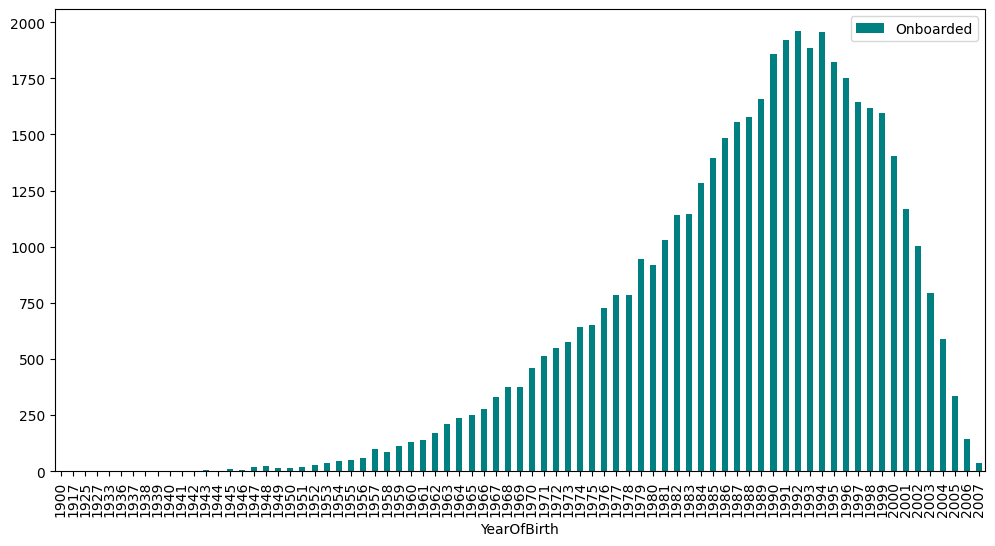

In [47]:


# --- 4) Agrupar por rango de edad y Transacting
counts = (df.groupby(['YearOfBirth','Transacting'])
                  .size()
                  .reset_index(name='n_usuarios'))

# --- 5) Pivot para gráfico
pivot = counts.pivot(index='YearOfBirth', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']


# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)


pivot.head(20)



#Estadística Descriptiva


## #Usuarios por mes

/tmp/ipython-input-3547179709.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['YMD'] = pd.to_datetime(df['YMD'], errors='coerce')
/tmp/ipython-input-3547179709.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['year_month'] = df2['YMD'].dt.to_period('M').astype(str)


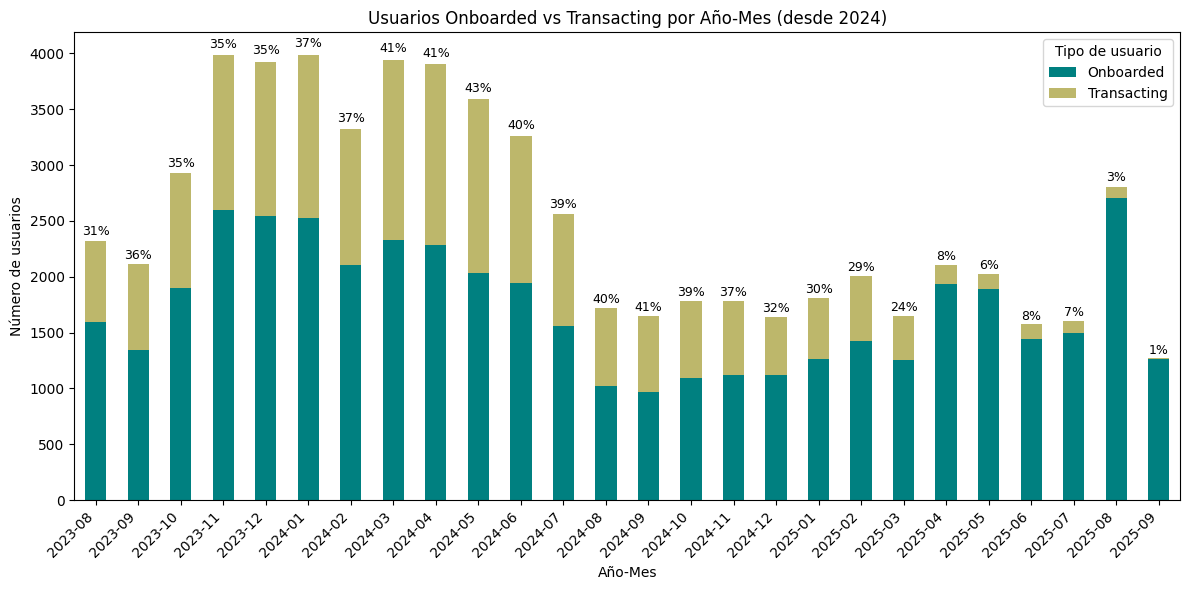

In [48]:


# --- 1) Asegura que la columna YMD sea datetime
df['YMD'] = pd.to_datetime(df['YMD'], errors='coerce')

# --- 1b) Filtrar solo fechas desde enero 2024
df2 = df[df['YMD'] >= "2023-08-01"]

# --- 2) Crea columna Año-Mes (YYYY-MM)
df2['year_month'] = df2['YMD'].dt.to_period('M').astype(str)

# --- 3) Agrupa por mes y Transacting
counts = (df2.groupby(['year_month','Transacting'])
            .size()
            .reset_index(name='n_usuarios'))

# --- 4) Pivot para graficar
pivot = counts.pivot(index='year_month', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 5) % transaccionales
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas de % (redondeado a 0 decimales)
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"{pct:.0f}%",          # ← redondeado a enteros
            ha='center', va='bottom',
            fontsize=9, color='black'
        )
# --- 8) Detalles del gráfico
plt.title("Usuarios Onboarded vs Transacting por Año-Mes (desde 2024)")
plt.xlabel("Año-Mes")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()

##Top 10 Entidades con más usuarios

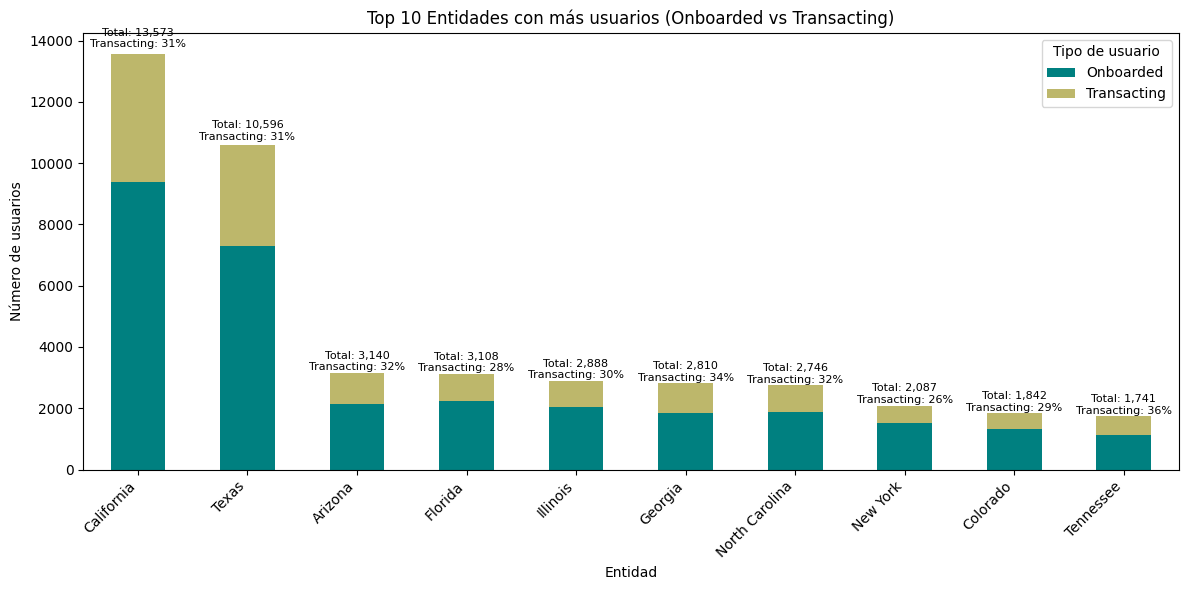

In [49]:
import matplotlib.pyplot as plt

# --- 3) Agrupa por estado y Transacting
counts = (df.groupby(['state_name','Transacting'])
            .size()
            .reset_index(name='n_usuarios'))

# --- 4) Pivot para graficar
pivot = counts.pivot(index='state_name', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 5) Calcula % transacting por estado
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 5b) Ordena por total y selecciona top 10
pivot['Total'] = pivot['Onboarded'] + pivot['Transacting']
pivot = pivot.sort_values('Total', ascending=False).head(10)

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas detalladas
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",  # formato con comas
            ha='center', va='bottom',
            fontsize=8,   # ajusta aquí el tamaño de letra
            color='black'
        )

# --- 8) Detalles del gráfico
plt.title("Top 10 Entidades con más usuarios (Onboarded vs Transacting)")
plt.xlabel("Entidad")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=45, ha='right')
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()

##Mapa geográfico del # usuarios por codigo postal

In [50]:
import pydeck as pdk
import pandas as pd

# Agrupa por ZIP
zip_group = df.groupby("postal_code").agg({
    "lat":"mean",
    "lng":"mean",
    "AccountUuid":"count"
}).reset_index().rename(columns={"AccountUuid":"count"})

# Capa de columnas (barras 3D)
layer = pdk.Layer(
    "ColumnLayer",
    data=zip_group,
    get_position=["lng", "lat"],
    get_elevation="count",
    elevation_scale=2000,
    radius=3000,
    get_fill_color="[255, count*10, 0]",
    pickable=True,
    auto_highlight=True,
)

view_state = pdk.ViewState(latitude=39.5, longitude=-98.35, zoom=3.4, pitch=30)

r = pdk.Deck(layers=[layer],
             initial_view_state=view_state,
             map_provider="carto",   # opciones: 'carto', 'mapbox'
             map_style="light",       # carto: 'light', 'dark', 'voyager', 'positron'
             tooltip={"text": "ZIP: {postal_code}\nUsuarios: {count}"})
r.to_html("mapa.html")



<IPython.core.display.Javascript object>

##Usuarios Onboarded vs Transacting por Rango de Edad

/tmp/ipython-input-3105705881.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  counts = (df_age.groupby(['RangoEdad','Transacting'])


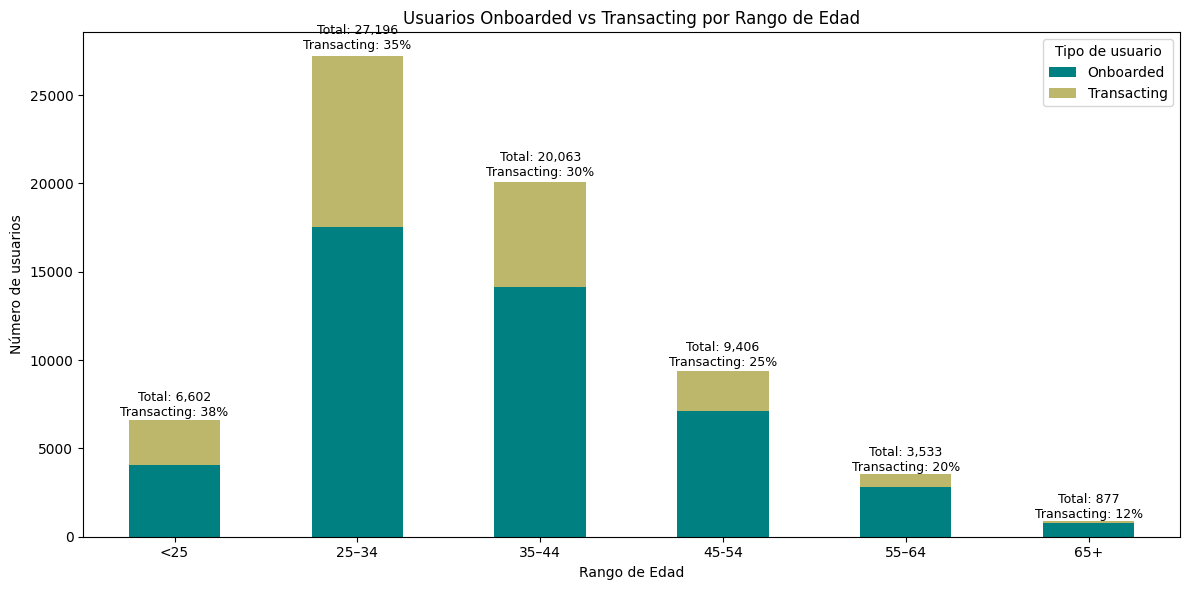

In [51]:

# --- 1) Año actual
year_now = pd.Timestamp.now().year

# --- 2) Calcular edad y filtrar outliers
df_age = df.copy()
df_age['Edad'] = year_now - df_age['YearOfBirth']
df_age = df_age[df_age['YearOfBirth'] != 1900]  # excluir outlier

# --- 3) Definir rangos de edad
bins = [0, 24, 34, 44, 54,64, 120]  # puedes ajustar el último valor
labels = ['<25','25–34','35–44','45-54','55–64','65+']
df_age['RangoEdad'] = pd.cut(df_age['Edad'], bins=bins, labels=labels, right=True)

# --- 4) Agrupar por rango de edad y Transacting
counts = (df_age.groupby(['RangoEdad','Transacting'])
                  .size()
                  .reset_index(name='n_usuarios'))

# --- 5) Pivot para gráfico
pivot = counts.pivot(index='RangoEdad', columns='Transacting', values='n_usuarios').fillna(0)
pivot.columns = ['Onboarded','Transacting']

# --- 6) % transaccionales
pivot['% Transacting'] = (pivot['Transacting'] / (pivot['Onboarded'] + pivot['Transacting'])) * 100

# --- 6) Gráfico de barras apiladas
ax = pivot[['Onboarded','Transacting']].plot(
    kind='bar', stacked=True, figsize=(12,6),
    color=['teal','darkkhaki']
)

# --- 7) Agregar etiquetas detalladas
for idx, (onb, tra, pct) in enumerate(zip(pivot['Onboarded'], pivot['Transacting'], pivot['% Transacting'])):
    total = onb + tra
    if total > 0:
        ax.text(
            idx, total + total*0.01,
            f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",  # formato con comas
            ha='center', va='bottom',
            fontsize=9,   # ajusta aquí el tamaño de letra
            color='black'
        )
# --- 9) Detalles
plt.title("Usuarios Onboarded vs Transacting por Rango de Edad")
plt.xlabel("Rango de Edad")
plt.ylabel("Número de usuarios")
plt.xticks(rotation=0)
plt.legend(title="Tipo de usuario")
plt.tight_layout()
plt.show()


##Distribución % de Usuarios Onboarded vs Transacting por Rango de Edad y Estado

/tmp/ipython-input-1282436697.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_age.groupby(['state_name', 'RangoEdad', 'Transacting'])
/tmp/ipython-input-1282436697.py:27: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  counts.pivot_table(


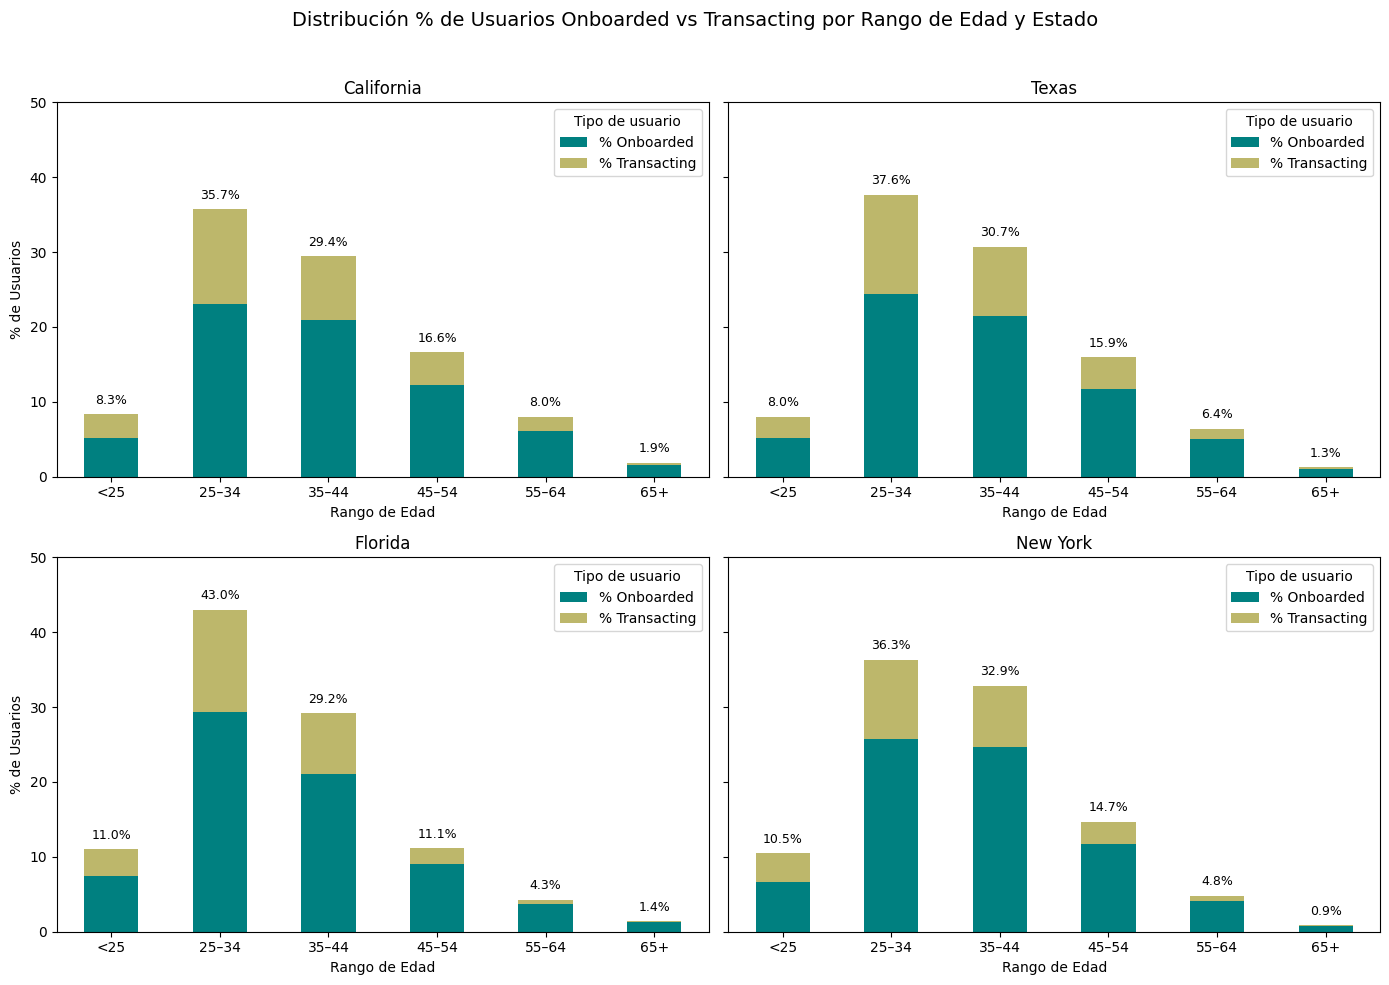

In [52]:

# --- 1) Año actual
year_now = pd.Timestamp.now().year

# --- 2) Calcular edad y filtrar outliers
df_age = df.copy()
df_age['Edad'] = year_now - df_age['YearOfBirth']
df_age = df_age[df_age['YearOfBirth'] != 1900]

# --- 3) Definir rangos de edad
bins = [0, 24, 34, 44, 54, 64, 120]
labels = ['<25','25–34','35–44','45–54','55–64','65+']
df_age['RangoEdad'] = pd.cut(df_age['Edad'], bins=bins, labels=labels, right=True)

# --- 4) Filtrar estados
estados_seleccion = ['California', 'Texas', 'Florida', 'New York']
df_age = df_age[df_age['state_name'].isin(estados_seleccion)]

# --- 5) Agrupar
counts = (
    df_age.groupby(['state_name', 'RangoEdad', 'Transacting'])
    .size()
    .reset_index(name='n_usuarios')
)

# --- 6) Pivot y total por estado
pivot = (
    counts.pivot_table(
        index=['state_name','RangoEdad'],
        columns='Transacting',
        values='n_usuarios',
        fill_value=0
    )
    .reset_index()
)
pivot.columns.name = None
pivot = pivot.rename(columns={0:'Onboarded',1:'Transacting'})

# --- 7) Calcular total y porcentajes dentro de cada estado
pivot['Total'] = pivot['Onboarded'] + pivot['Transacting']
pivot['% Onboarded'] = pivot['Onboarded'] / pivot.groupby('state_name')['Total'].transform('sum') * 100
pivot['% Transacting'] = pivot['Transacting'] / pivot.groupby('state_name')['Total'].transform('sum') * 100

# --- 8) Graficar en % por estado
fig, axes = plt.subplots(2, 2, figsize=(14,10), sharey=True)
axes = axes.flatten()

for i, estado in enumerate(estados_seleccion):
    subset = pivot[pivot['state_name'] == estado].copy()

    # Asegura orden y presencia de todos los rangos
    subset = (subset.set_index('RangoEdad')
                      .reindex(labels)            # respeta el orden de categorías
                      .fillna({'Onboarded':0, 'Transacting':0, '% Onboarded':0, '% Transacting':0, 'Total':0})
                      .reset_index())

    # Plot apilado en %
    ax = subset[['RangoEdad','% Onboarded','% Transacting']].set_index('RangoEdad') \
         .plot(kind='bar', stacked=True, color=['teal','darkkhaki'], ax=axes[i])

    # Etiqueta dinámica justo arriba de cada barra (% total de ese rango)
    total_pct_col = (subset['% Onboarded'] + subset['% Transacting']).to_numpy()
    for x, h in enumerate(total_pct_col):
        ax.text(x, h + 1, f"{h:.1f}%", ha='center', va='bottom', fontsize=9, color='black')


    axes[i].set_title(estado)
    axes[i].set_xlabel("Rango de Edad")
    axes[i].set_ylabel("% de Usuarios")
    axes[i].legend(title="Tipo de usuario")
    axes[i].set_xticklabels(labels, rotation=0)
    axes[i].set_ylim(0, 50)  # deja espacio para etiquetas

plt.suptitle("Distribución % de Usuarios Onboarded vs Transacting por Rango de Edad y Estado", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##Distribución de usuarios de distintos atributos

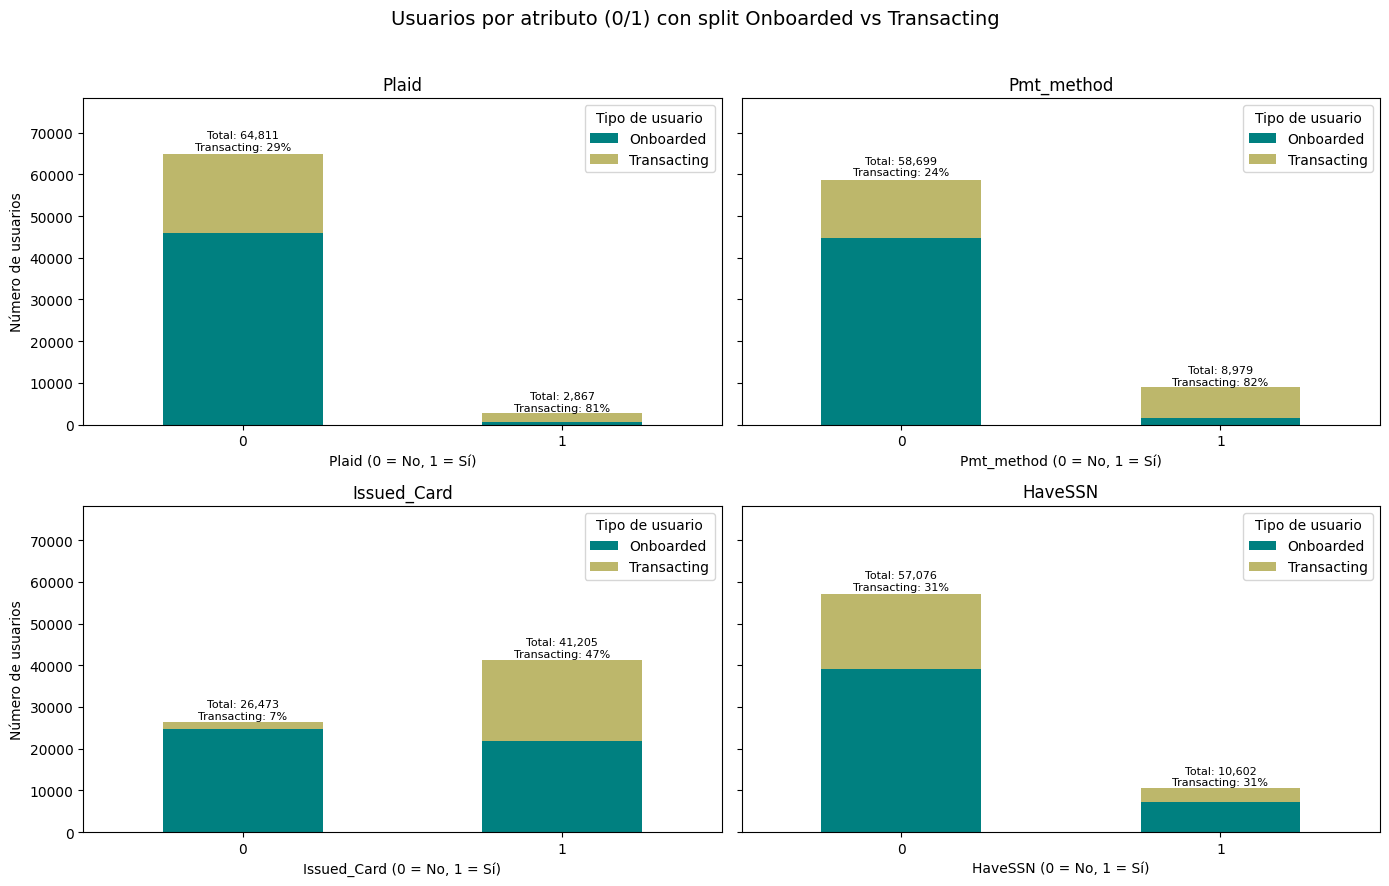

In [68]:


cols = ['Plaid', 'Pmt_method', 'Issued_Card', 'HaveSSN']

def to_binary(series):
    true_set  = {True, 1, 1.0, '1', 'true', 'True', 'yes', 'Yes', 'y', 'Y', 'si', 'Sí', 'SI'}
    false_set = {False, 0, 0.0, '0', 'false', 'False', 'no', 'No', 'n', 'N'}
    def map_val(v):
        if pd.isna(v): return np.nan
        if v in true_set: return 1
        if v in false_set: return 0
        try:
            fv = float(v)
            if fv == 1.0: return 1
            if fv == 0.0: return 0
        except:
            pass
        return np.nan
    return series.apply(map_val)

# --- Normaliza columna Transacting ---
transacting_bin = to_binary(df['Transacting']).astype('Int64')

# --- Crear figura 2x2 ---
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharey=True)
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]

    if col not in df.columns:
        ax.axis('off')
        ax.set_title(f"{col} (no existe en df)")
        continue

    # --- Normaliza la variable ---
    col_bin = to_binary(df[col]).astype('Int64')
    mask = col_bin.isin([0,1]) & transacting_bin.isin([0,1])
    dfx = pd.DataFrame({
        col: col_bin[mask].astype(int),
        'Transacting': transacting_bin[mask].astype(int)
    })

    if dfx.empty:
        ax.axis('off')
        ax.set_title(f"{col} (sin datos válidos)")
        continue

    # --- Crosstab ---
    ct = pd.crosstab(dfx[col], dfx['Transacting'])
    for c in [0,1]:
        if c not in ct.columns:
            ct[c] = 0
    for r in [0,1]:
        if r not in ct.index:
            ct.loc[r, :] = 0
    ct = ct.sort_index()[[0,1]]
    ct_plot = ct.rename(columns={0:'Onboarded', 1:'Transacting'})

    # --- Plot apilado ---
    ct_plot.plot(kind='bar', stacked=True, color=['teal','darkkhaki'], edgecolor='none', ax=ax)

    # --- Etiquetas estilo "Total / % Transacting" ---
    for idx, (onb, tra) in enumerate(zip(ct_plot['Onboarded'], ct_plot['Transacting'])):
        total = onb + tra
        pct = (tra / total * 100) if total > 0 else 0
        if total > 0:
            ax.text(
                idx, total + total * 0.01,
                f"Total: {total:,.0f}\nTransacting: {pct:.0f}%",
                ha='center', va='bottom',
                fontsize=8,
                color='black'
            )

    # --- Estilo del subplot ---
    ax.set_title(col)
    ax.set_xlabel(f"{col} (0 = No, 1 = Sí)")
    ax.set_ylabel("Número de usuarios")
    ax.set_xticklabels(['0','1'], rotation=0)
    ax.legend(title="Tipo de usuario", loc="upper right")
    ax.set_ylim(0, ct_plot.values.max().max() * 2)

plt.suptitle("Usuarios por atributo (0/1) con split Onboarded vs Transacting", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


##Correlación entre #Usuarios y %de Hispanos por codigo postal

Correlación (solo California): 0.507


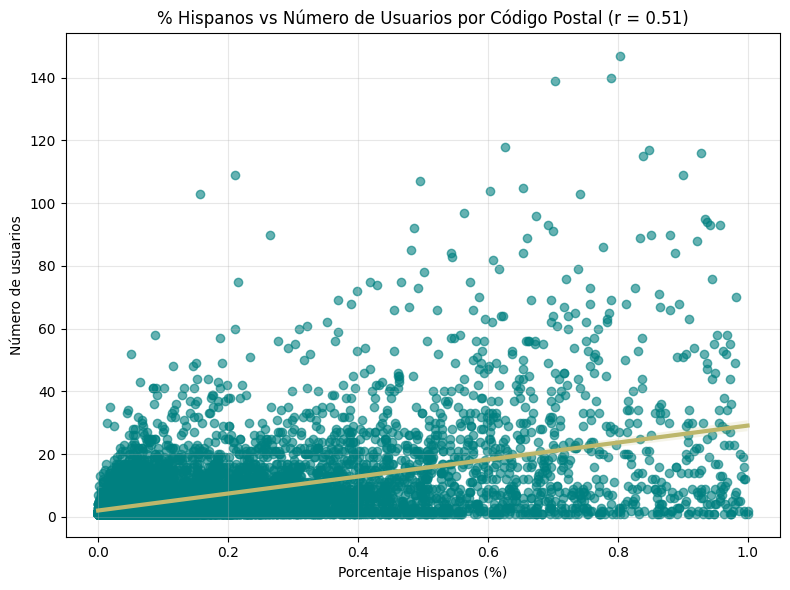

In [55]:


# --- 2) Agrupa por ZIP (solo California)
zip_group = df.groupby("postal_code").agg({
    "Hispanic_percent": "mean",    # promedio del porcentaje
    "AccountUuid": "count"         # conteo de usuarios
}).reset_index().rename(columns={"AccountUuid": "user_count"})

# --- 3) Calcular correlación
corr = zip_group['Hispanic_percent'].corr(zip_group['user_count'])
print(f"Correlación (solo California): {corr:.3f}")

# --- 4) Scatter plot
plt.figure(figsize=(8,6))
sns.regplot(
    data=zip_group,
    x="Hispanic_percent",
    y="user_count",
    scatter_kws={"alpha":0.6, "color":"teal"},
    line_kws={"color":"darkkhaki", "lw":3}
)

# --- 5) Etiquetas y formato
plt.title(f"% Hispanos vs Número de Usuarios por Código Postal (r = {corr:.2f})", fontsize=12)
plt.xlabel("Porcentaje Hispanos (%)")
plt.ylabel("Número de usuarios")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()